# Experiment 2.1 — Hurdle MLP, xP-excluded

**Reframed expectation (informed by Experiment 2.0 diagnostics):**

The 2.0 diagnostic showed Stage 2 R² alone = 0.085 on a regularization-flat loss surface, which means the conditional points-given-play problem has very little linear signal once `xP` is removed. The MLP's headroom is bounded by what nonlinear interactions can extract from the same feature set, not by xP's information content (which is genuinely absent from raw historical stats — team strength, fixture difficulty, set-piece status, bookmaker rates).

**Calibrated targets:**

| Metric | Expected range | Interpretation |
|---|---|---|
| Stage 2 alone R² (MLP) | 0.10 – 0.18 | Linear was 0.085. Real interactions could lift this; magic can't. |
| Combined hurdle R² | 0.32 – 0.36 | 2.0 was 0.30. Stage 1 (LR, AUC 0.93) carries most of the variance explained. |
| Combined hurdle MAE | 0.92 – 0.96 | 2.0 was 0.976. Modest improvement expected. |

**If combined R² ≥ 0.40 — check for leakage before celebrating.** That would require Stage 2 to roughly triple over linear on a flat loss surface, which is unusual. More likely cause: a feature scaling bug, a train/val mix-up, or `played_any` slipping back into the feature list.

**Substitutions vs Phase 2 spec:**

- `MLPRegressor` from sklearn instead of torch/keras → L2 (`alpha`) instead of dropout, consistent with Phase 1 ecosystem
- Two-layer holdout: temporal early-stop set (final 5 GWs of 22/23) for hyperparameter selection, sklearn's random `validation_fraction=0.1` for per-config early stopping. Val (23/24) untouched.


## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("./data/processed/fpl_modeling_data.csv")
df = pd.read_csv(DATA_PATH)

TRAIN_SEASONS  = ["2021-22", "2022-23"]
HOLDOUT_SEASON = "2023-24"
TEST_GW_START  = 34
ES_SEASON      = "2022-23"   # early-stop set: final 5 GWs of 22/23
ES_GW_START    = 34

train_mask = df["season"].isin(TRAIN_SEASONS)
val_mask   = (df["season"] == HOLDOUT_SEASON) & (df["GW"] < TEST_GW_START)
es_mask    = (df["season"] == ES_SEASON) & (df["GW"] >= ES_GW_START)
train_minus_es_mask = train_mask & ~es_mask

played_train_minus_es_mask = train_minus_es_mask & (df["played_any"] == 1)
played_es_mask             = es_mask             & (df["played_any"] == 1)
played_val_mask            = val_mask            & (df["played_any"] == 1)

EXCLUDE = {"name", "name_key", "season", "GW", "player_season", "team", "position",
           "total_points", "played_any", "played_60min", "cluster_id"}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features_no_xp = [c for c in numeric_cols if c not in EXCLUDE and c != "xP"]

print(f"Features (no xP):                {len(features_no_xp)}")
print(f"Train (full, all rows):          {train_mask.sum():,}")
print(f"  Train minus ES (played-only):  {played_train_minus_es_mask.sum():,}")
print(f"  Early-stop set (played-only):  {played_es_mask.sum():,}  (22/23 GW {ES_GW_START}–38)")
print(f"Val (23/24 GW 2–33, all rows):   {val_mask.sum():,}")
print(f"  Val played-only:               {played_val_mask.sum():,}")


Features (no xP):                43
Train (full, all rows):          46,991
  Train minus ES (played-only):  18,492
  Early-stop set (played-only):  1,530  (22/23 GW 34–38)
Val (23/24 GW 2–33, all rows):   23,825
  Val played-only:               9,257


## 2. Stage 1 — Logistic Regression (no xP)

Same as Experiment 2.0. Fits on the full train set including the early-stop GWs (Stage 1 doesn't need early stopping; LR is a convex optimization). Produces `P(play)` predictions on the val set.


In [3]:
X_train_s1 = df.loc[train_mask, features_no_xp].values
y_train_s1 = df.loc[train_mask, "played_any"].values
X_val_s1   = df.loc[val_mask,   features_no_xp].values
y_val_s1   = df.loc[val_mask,   "played_any"].values

scaler_s1 = StandardScaler().fit(X_train_s1)
lr_s1 = LogisticRegression(max_iter=2000, random_state=SEED).fit(
    scaler_s1.transform(X_train_s1), y_train_s1
)
p_play_no_xp = lr_s1.predict_proba(scaler_s1.transform(X_val_s1))[:, 1]
auc = roc_auc_score(y_val_s1, p_play_no_xp)
print(f"Stage 1 LR no-xP val AUC: {auc:.4f}")


Stage 1 LR no-xP val AUC: 0.9300


## 3. Stage 2 — MLP setup

Scaler fit on `train_minus_es` played-only rows. Applied to early-stop set and val without refitting. The early-stop set is held out from Stage 2 training and used only for hyperparameter selection.


In [4]:
# Stage 2 training data: played-only train rows MINUS the early-stop GWs
X_train_s2_raw = df.loc[played_train_minus_es_mask, features_no_xp].values
y_train_s2     = df.loc[played_train_minus_es_mask, "total_points"].values

X_es_raw       = df.loc[played_es_mask,    features_no_xp].values
y_es           = df.loc[played_es_mask,    "total_points"].values

X_val_full_raw   = df.loc[val_mask,        features_no_xp].values
X_val_played_raw = df.loc[played_val_mask, features_no_xp].values

scaler_s2 = StandardScaler().fit(X_train_s2_raw)
X_train_s2   = scaler_s2.transform(X_train_s2_raw)
X_es         = scaler_s2.transform(X_es_raw)
X_val_full   = scaler_s2.transform(X_val_full_raw)
X_val_played = scaler_s2.transform(X_val_played_raw)

y_val_full   = df.loc[val_mask,        "total_points"].values
y_val_played = df.loc[played_val_mask, "total_points"].values

print(f"X_train_s2: {X_train_s2.shape}")
print(f"X_es:       {X_es.shape}")
print(f"X_val_full: {X_val_full.shape}  ({played_val_mask.sum():,} played-only rows)")


X_train_s2: (18492, 43)
X_es:       (1530, 43)
X_val_full: (23825, 43)  (9,257 played-only rows)


## 4. Hyperparameter grid search

3×3 grid over `hidden_layer_sizes` and `alpha` (L2). Learning rate fixed at 1e-3 (Adam default, also Phase 2 plan default). Selection metric: MAE on the temporal early-stop set.


In [5]:
hidden_options = [(64,), (64, 32), (128, 64, 32)]
alpha_options  = [1e-4, 1e-3, 1e-2]

results = []
for hidden in hidden_options:
    for alpha in alpha_options:
        mlp = MLPRegressor(
            hidden_layer_sizes=hidden,
            alpha=alpha,
            learning_rate_init=1e-3,
            activation="relu",
            solver="adam",
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=SEED,
        )
        mlp.fit(X_train_s2, y_train_s2)
        pred_es = mlp.predict(X_es)
        results.append({
            "hidden": str(hidden),
            "alpha":  alpha,
            "n_iter": mlp.n_iter_,
            "es_R²":  round(r2_score(y_es, pred_es), 4),
            "es_MAE": round(mean_absolute_error(y_es, pred_es), 4),
        })

results_df = pd.DataFrame(results).sort_values("es_MAE").reset_index(drop=True)
print(results_df.to_string(index=False))

best_row = results_df.iloc[0]
print(f"\nBest config (lowest es_MAE):")
print(f"  hidden_layer_sizes = {best_row['hidden']}")
print(f"  alpha              = {best_row['alpha']}")
print(f"  es_R²              = {best_row['es_R²']}")
print(f"  es_MAE             = {best_row['es_MAE']}")


       hidden  alpha  n_iter  es_R²  es_MAE
(128, 64, 32) 0.0001      22 0.1506  2.1255
(128, 64, 32) 0.0100      22 0.1502  2.1255
(128, 64, 32) 0.0010      22 0.1517  2.1270
        (64,) 0.0001      46 0.1458  2.1462
        (64,) 0.0100      46 0.1450  2.1474
        (64,) 0.0010      46 0.1453  2.1484
     (64, 32) 0.0100      29 0.1538  2.1585
     (64, 32) 0.0010      29 0.1545  2.1629
     (64, 32) 0.0001      22 0.1469  2.2228

Best config (lowest es_MAE):
  hidden_layer_sizes = (128, 64, 32)
  alpha              = 0.0001
  es_R²              = 0.1506
  es_MAE             = 2.1255


## 5. Refit best config and produce final predictions

Refit the best configuration on `train_minus_es` only (no leakage of early-stop set into final model). Generate combined hurdle predictions on val.


In [6]:
# Parse best config back from the results row
best_hidden = eval(best_row["hidden"])
best_alpha  = best_row["alpha"]

best_mlp = MLPRegressor(
    hidden_layer_sizes=best_hidden,
    alpha=best_alpha,
    learning_rate_init=1e-3,
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
).fit(X_train_s2, y_train_s2)

cond_points_full   = best_mlp.predict(X_val_full)
cond_points_played = best_mlp.predict(X_val_played)
y_pred             = p_play_no_xp * cond_points_full

print(f"Best MLP trained {best_mlp.n_iter_} iterations before early stop")


Best MLP trained 22 iterations before early stop


## 6. Combined hurdle evaluation

In [7]:
r2_combined  = r2_score(y_val_full, y_pred)
mae_combined = mean_absolute_error(y_val_full, y_pred)

print(f"Combined hurdle (no xP, MLP) val R²:  {r2_combined:.4f}")
print(f"Combined hurdle (no xP, MLP) val MAE: {mae_combined:.4f}")
print(f"\nReference:")
print(f"  Phase 1 hurdle WITH xP:           R² 0.6386, MAE 0.7116")
print(f"  Phase 1 hurdle WITHOUT xP (2.0):  R² 0.2999, MAE 0.9762")
print(f"  xP passthrough:                   R² 0.5169, MAE 0.8129")

print(f"\n--- Calibration check ---")
if r2_combined >= 0.40:
    print(f"⚠️  R² = {r2_combined:.4f} ≥ 0.40 — investigate before celebrating.")
    print(f"   Expected range was 0.32–0.36. Check: feature scaling, train/val split, played_any leakage.")
elif r2_combined >= 0.32:
    print(f"✓  R² = {r2_combined:.4f} in expected range (0.32–0.36). MLP captured what it could.")
elif r2_combined >= 0.30:
    print(f"~  R² = {r2_combined:.4f} essentially matches 2.0 ({0.2999}). MLP added little — consistent with the flat-loss-surface diagnostic.")
else:
    print(f"⚠️  R² = {r2_combined:.4f} below 2.0 ({0.2999}). Possible bug — investigate before iterating.")


Combined hurdle (no xP, MLP) val R²:  0.2887
Combined hurdle (no xP, MLP) val MAE: 0.9625

Reference:
  Phase 1 hurdle WITH xP:           R² 0.6386, MAE 0.7116
  Phase 1 hurdle WITHOUT xP (2.0):  R² 0.2999, MAE 0.9762
  xP passthrough:                   R² 0.5169, MAE 0.8129

--- Calibration check ---
⚠️  R² = 0.2887 below 2.0 (0.2999). Possible bug — investigate before iterating.


## 7. Per-position MAE comparison vs 2.0

In [8]:
# 2.0 per-position MAE (from previous notebook output)
mae_2_0 = {"GK": 0.6188, "DEF": 1.0641, "MID": 0.9880, "FWD": 1.0340}

val_df = df.loc[val_mask].assign(
    y_pred=y_pred,
    abs_err=lambda d: np.abs(d["total_points"] - d["y_pred"]),
)
per_pos = (
    val_df.groupby("position")
          .agg(n=("abs_err", "size"), mae_2_1=("abs_err", "mean"))
          .reindex(["GK", "DEF", "MID", "FWD"])
)
per_pos["mae_2_0"] = [mae_2_0[p] for p in per_pos.index]
per_pos["delta"]   = per_pos["mae_2_1"] - per_pos["mae_2_0"]
per_pos = per_pos[["n", "mae_2_0", "mae_2_1", "delta"]].round(4)
print(per_pos.to_string())
print("\nNegative delta = MLP improves over 2.0; positive = worse.")


              n  mae_2_0  mae_2_1   delta
position                                 
GK         2736   0.6188   0.6135 -0.0053
DEF        7710   1.0641   1.0620 -0.0021
MID       10300   0.9880   0.9598 -0.0282
FWD        3079   1.0340   1.0325 -0.0015

Negative delta = MLP improves over 2.0; positive = worse.


## 8. Diagnostic — Training curve

Loss vs iteration for the best config. Sklearn's internal validation is a random 10% of `train_minus_es` (left axis: training MSE; right axis: sklearn val R²). Vertical line marks where early stopping triggered.


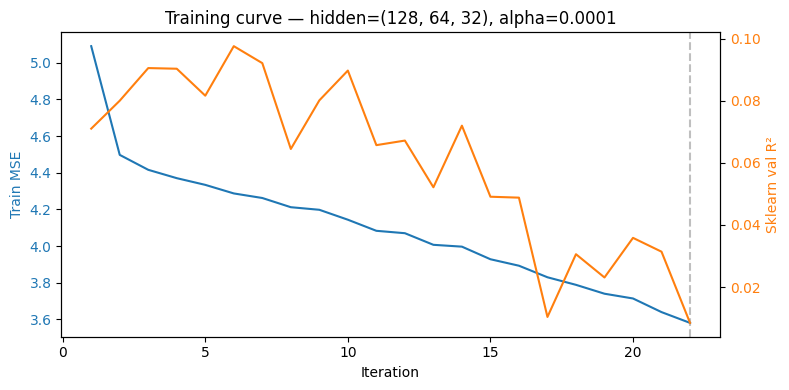

Temporal es_set (final 5 GWs of 22/23) R²:  0.1506
Temporal es_set MAE:                        2.1255


In [9]:
fig, ax1 = plt.subplots(figsize=(8, 4))

epochs = np.arange(1, len(best_mlp.loss_curve_) + 1)
ax1.plot(epochs, best_mlp.loss_curve_, label="Train MSE", color="tab:blue")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Train MSE", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(epochs, best_mlp.validation_scores_, label="Sklearn val R²", color="tab:orange")
ax2.set_ylabel("Sklearn val R²", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.axvline(best_mlp.n_iter_, ls="--", color="gray", alpha=0.5, label=f"Stopped at iter {best_mlp.n_iter_}")
ax1.set_title(f"Training curve — hidden={best_hidden}, alpha={best_alpha}")
fig.tight_layout()
plt.show()

# Final temporal es_set check (independent of sklearn's random val)
es_pred = best_mlp.predict(X_es)
print(f"Temporal es_set (final 5 GWs of 22/23) R²:  {r2_score(y_es, es_pred):.4f}")
print(f"Temporal es_set MAE:                        {mean_absolute_error(y_es, es_pred):.4f}")


## 9. Diagnostic — Permutation feature importance

Computed on played-only val rows for the Stage 2 MLP (isolates what the network relies on for the conditional points task). Compare qualitatively to Phase 1's Lasso top coefficients.


In [10]:
perm = permutation_importance(
    best_mlp, X_val_played, y_val_played,
    n_repeats=10, random_state=SEED, n_jobs=-1, scoring="r2"
)
imp = pd.Series(perm.importances_mean, index=features_no_xp).sort_values(ascending=False)

top10 = imp.head(10).round(4)
print("Top 10 features by permutation importance (mean R² drop when permuted):")
print(top10.to_string())

print("\nFor reference, Experiment 2.0's no-xP Lasso top 10:")
print("  is_dgw, value, minutes_roll3, pos_GK, transfers_in, pos_DEF,")
print("  selected, minutes_lag1, goals_conceded_roll3, influence_roll3")


Top 10 features by permutation importance (mean R² drop when permuted):
value                0.0519
pos_GK               0.0155
transfers_balance    0.0118
transfers_in         0.0087
minutes_roll3        0.0082
selected             0.0080
bps_roll3            0.0077
threat_roll3         0.0069
pos_MID              0.0057
goals_scored_lag1    0.0049

For reference, Experiment 2.0's no-xP Lasso top 10:
  is_dgw, value, minutes_roll3, pos_GK, transfers_in, pos_DEF,
  selected, minutes_lag1, goals_conceded_roll3, influence_roll3


## 10. Diagnostic — Residual plot

Combined hurdle predictions vs residuals on val. Looking for systematic structure (e.g., under-prediction at high predicted values would suggest the model is shrinkage-biased and a calibration step might help).


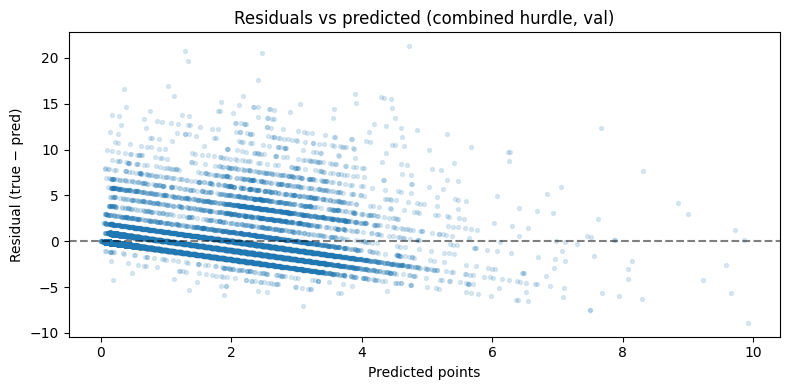


Residuals binned by predicted-points decile:
                        n  mean_pred  mean_true  mean_resid
bin                                                        
(-0.0009087, 0.119]  2383      0.076      0.043      -0.034
(0.119, 0.132]       2382      0.126      0.031      -0.095
(0.132, 0.151]       2383      0.141      0.043      -0.099
(0.151, 0.18]        2382      0.162      0.123      -0.040
(0.18, 0.273]        2383      0.218      0.241       0.023
(0.273, 0.531]       2382      0.379      0.533       0.154
(0.531, 1.345]       2382      0.871      1.346       0.474
(1.345, 2.163]       2383      1.806      2.059       0.253
(2.163, 2.824]       2382      2.477      2.704       0.227
(2.824, 9.913]       2383      3.609      3.621       0.013


In [11]:
residuals = y_val_full - y_pred

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_pred, residuals, alpha=0.15, s=8)
ax.axhline(0, ls="--", color="black", alpha=0.5)
ax.set_xlabel("Predicted points")
ax.set_ylabel("Residual (true − pred)")
ax.set_title("Residuals vs predicted (combined hurdle, val)")
plt.tight_layout()
plt.show()

# Bin residuals by predicted-points decile to surface any systematic under/over-prediction
bins = pd.qcut(y_pred, q=10, duplicates="drop")
binned = pd.DataFrame({"y_true": y_val_full, "y_pred": y_pred, "resid": residuals, "bin": bins})
summary = binned.groupby("bin", observed=True).agg(
    n=("resid", "size"),
    mean_pred=("y_pred", "mean"),
    mean_true=("y_true", "mean"),
    mean_resid=("resid", "mean"),
).round(3)
print("\nResiduals binned by predicted-points decile:")
print(summary.to_string())


## 11. Sanity check — Stage 2 alone R²

This is the apples-to-apples comparison with the diagnostic from 2.0 (linear Stage 2 alone R² = 0.0852). It isolates the MLP's contribution to the conditional points-given-play problem.


In [12]:
r2_s2_mlp  = r2_score(y_val_played, cond_points_played)
mae_s2_mlp = mean_absolute_error(y_val_played, cond_points_played)

print(f"MLP Stage 2 alone (played-only val):")
print(f"  R²:  {r2_s2_mlp:.4f}   (linear was 0.0852)")
print(f"  MAE: {mae_s2_mlp:.4f}   (linear was 2.0357)")

delta_r2 = r2_s2_mlp - 0.0852
print(f"\nMLP gain over linear Stage 2: ΔR² = {delta_r2:+.4f}")
if delta_r2 < 0.01:
    print("Conclusion: MLP captures essentially nothing beyond linear. Confirms (b) — signal availability is the bottleneck.")
elif delta_r2 < 0.05:
    print("Conclusion: Modest nonlinear signal. Some interactions exist but are small relative to the missing-feature gap.")
else:
    print("Conclusion: Real nonlinear signal recovered. Worth investigating which interactions matter (permutation importance above).")


MLP Stage 2 alone (played-only val):
  R²:  0.0681   (linear was 0.0852)
  MAE: 1.9954   (linear was 2.0357)

MLP gain over linear Stage 2: ΔR² = -0.0171
Conclusion: MLP captures essentially nothing beyond linear. Confirms (b) — signal availability is the bottleneck.


## 12. Phase 2 final summary

In [13]:
summary = pd.DataFrame([
    {"Model": "xP passthrough (Phase 1 reference)",     "Val R²": 0.5169,             "Val MAE": 0.8129},
    {"Model": "Phase 1 hurdle WITH xP (ceiling)",       "Val R²": 0.6386,             "Val MAE": 0.7116},
    {"Model": "Phase 1 hurdle WITHOUT xP (Exp 2.0)",    "Val R²": 0.2999,             "Val MAE": 0.9762},
    {"Model": "Hurdle MLP, xP-excluded (Exp 2.1)",      "Val R²": round(r2_combined, 4), "Val MAE": round(mae_combined, 4)},
])
print(summary.to_string(index=False))

xp_value_total = 0.6386 - 0.2999          # gap explained by xP in linear regime
xp_value_recovered = r2_combined - 0.2999 # gap recovered by going nonlinear without xP
pct = 100 * xp_value_recovered / xp_value_total if xp_value_total > 0 else 0

print(f"\nGap from xP (linear regime):           ΔR² = {xp_value_total:.4f}")
print(f"Recovered by MLP (nonlinearity, no xP): ΔR² = {xp_value_recovered:+.4f}  ({pct:+.1f}% of the gap)")
print("\nFraming for writeup:")
print("  xP encodes pre-kickoff information not present in raw historical features —")
print("  team strength, fixture difficulty, set-piece status, bookmaker rates.")
print(f"  Stripping xP drops linear hurdle R² from 0.64 to 0.30. Replacing Stage 2")
print(f"  with an MLP recovers {xp_value_recovered:+.4f} of that 0.34 gap, suggesting the")
print("  residual reflects information genuinely absent from the feature set rather")
print("  than functional-form limitations of linear modeling.")


                              Model  Val R²  Val MAE
 xP passthrough (Phase 1 reference)  0.5169   0.8129
   Phase 1 hurdle WITH xP (ceiling)  0.6386   0.7116
Phase 1 hurdle WITHOUT xP (Exp 2.0)  0.2999   0.9762
  Hurdle MLP, xP-excluded (Exp 2.1)  0.2887   0.9625

Gap from xP (linear regime):           ΔR² = 0.3387
Recovered by MLP (nonlinearity, no xP): ΔR² = -0.0112  (-3.3% of the gap)

Framing for writeup:
  xP encodes pre-kickoff information not present in raw historical features —
  team strength, fixture difficulty, set-piece status, bookmaker rates.
  Stripping xP drops linear hurdle R² from 0.64 to 0.30. Replacing Stage 2
  with an MLP recovers -0.0112 of that 0.34 gap, suggesting the
  residual reflects information genuinely absent from the feature set rather
  than functional-form limitations of linear modeling.
